In [73]:
import pandas as pd

In [125]:
import matplotlib.pyplot as plt

In [143]:
import numpy as np

In [74]:
df = pd.read_csv('../data/Wildlife_Export_2023_2025.csv', encoding='latin-1')

C:\Users\Dheick\AppData\Local\Temp\ipykernel_19948\3854085828.py:1: DtypeWarning: Columns (0: AIRPORT_LATITUDE, 1: AIRPORT_LONGITUDE, 2: BIRD_BAND_NUMBER, 3: LUPDATE) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/Wildlife_Export_2023_2025.csv', encoding='latin-1')


### Stripping the Column Headers

In [75]:
df.columns = df.columns.str.strip()

### Getting More Information About the Data
* There are 65,774 records for the time period between 2023 & 2025
* This dataset has 102 columns, much of this data can probably be dropped.

In [76]:
df.shape

(65774, 102)

### Checking the datatype for all columns
<u>Issues with the datatypes</u>
* `INCIDENT_DATE` is a string
* `TIME` is a string
* `NR_INJURIES` is a float
* `NR_FATALITIES` is a float

In [146]:
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 65774 entries, 0 to 65773
Data columns (total 103 columns):
 #    Column                 Non-Null Count  Dtype         
---   ------                 --------------  -----         
 0    INDX_NR                65774 non-null  int64         
 1    INCIDENT_DATE          65774 non-null  datetime64[us]
 2    INCIDENT_MONTH         65774 non-null  int64         
 3    INCIDENT_YEAR          65774 non-null  int64         
 4    TIME                   65774 non-null  str           
 5    TIME_OF_DAY            34364 non-null  str           
 6    AIRPORT_ID             65774 non-null  str           
 7    AIRPORT                65774 non-null  str           
 8    AIRPORT_LATITUDE       53792 non-null  object        
 9    AIRPORT_LONGITUDE      53789 non-null  object        
 10   RUNWAY                 65774 non-null  str           
 11   STATE                  53792 non-null  str           
 12   FAAREGION              53792 non-null  str           
 

### Checking how much of the data is null
* The following code creates the variable `null_pct` which will return the percentage of data that is missing from each column.
* The print statement will return all columns that have over **50%** of the data missing.
* I will consider this information in choosing which columns to keep.

In [78]:
null_pct = df.isnull().mean().sort_values(ascending=False) * 100
print(null_pct[null_pct > 50])

NR_FATALITIES            99.998480
NR_INJURIES              99.966552
BIRD_BAND_NUMBER         99.844924
ENG_4_POS                99.583422
COST_REPAIRS             99.367531
COST_REPAIRS_INFL_ADJ    99.367531
EFFECT_OTHER             99.329522
ENG_3_POS                99.116672
COST_OTHER_INFL_ADJ      98.624076
COST_OTHER               98.624076
ENROUTE_STATE            98.406665
AOS                      94.529753
OTHER_SPECIFY            82.473318
LOCATION                 81.979202
SPEED                    78.117493
COMMENTS                 71.199866
PRECIPITATION            64.008575
HEIGHT                   59.731809
SKY                      59.611701
EFFECT                   58.656916
AMO                      51.261897
dtype: float64


### Converting `INCIDENT_DATE` to `datetime`
* This code will convert `INCIDENT_DATE` to `datetime` which will provide for more robust data. 

In [79]:
df['INCIDENT_DATE'] = pd.to_datetime(df['INCIDENT_DATE'])

### Comparing TIME and TIME_OF_DAY
* `TIME` has Zero nulls
* `TIME_OF_DAY` is missing 47% of the data

In [80]:
print(df['TIME'].isna().sum(), df['TIME'].isna().mean())
print(df['TIME_OF_DAY'].isna().sum(), df['TIME_OF_DAY'].isna().mean())

0 0.0
31410 0.47754431842369327


### Considering and Adjusting `NR_INJURIES` and `NR_FATALITIES`
* `NR_INJURIES` and `NR_FATALITIES` are both floats. These should be converted to ints because a person is either injured or not.
* `NR_INJURIES` is 99.96% empty and `NR_FATALITIES` is 99.99% empty, but the data that does exist is still interesting enough to keep at this time.

In [81]:
df['NR_INJURIES'] = df['NR_INJURIES'].fillna(0).astype(int)

In [82]:
df['NR_FATALITIES'] = df['NR_FATALITIES'].fillna(0).astype(int)

### Checking for Duplicates
* There are no duplicate rows

In [83]:
df.duplicated().sum()

np.int64(0)

### Initial Observations About the Data
* `INCIDENT_YEAR` The number of bird strikes is increasing year-over-year from 2023 to 2025.
* `INCIDENT_MONTH` Most bird strikes are recorded in September, August, October and July. There seems to be a significant difference between the warmer and colder months.
* `STATE` The top 5 states are TX, FL, CA, CO and TN. This seems to track with where the busy airports are (perhaps I can bring some data in regarding airport activity). Kentuky made the top 10.
* `FAAREGION` There seems to be some duplication in the FAAREGION data. I will need to strip this column to normalize it.
* `AIRPORT` UKNOWN is by far the largest airport, I am curious why that is the case. My guess is that it because many of the bird strikes are from observation of evidence of a bird strike but a lack of clarity where it happened. The other airports make sense because they are large market hubs.
* `OPERATOR` Again, UNKNOWN is by far the largest operator followed by the other popular airlines. I do find it interesting that business beats Delta and United, as those are very popular airlines.
* `PHASE_OF_FLIGHT` This is interesting because it describes at what point a plane is most likely to have a bird strike. I will need to supliment my understanding of these phases of flight because I do not know what makes them distinct.




In [84]:
df['INCIDENT_YEAR'].value_counts()

INCIDENT_YEAR
2025    23779
2024    22370
2023    19625
Name: count, dtype: int64

In [85]:
df['INCIDENT_MONTH'].value_counts()

INCIDENT_MONTH
9     9112
8     9057
10    8639
7     8466
5     7133
6     5726
4     5012
11    4256
3     2822
12    1907
1     1892
2     1752
Name: count, dtype: int64

In [86]:
df['STATE'].value_counts().head(10)

STATE
TX    7207
FL    5384
CA    4305
CO    3189
TN    2412
IL    2279
NY    2142
MI    1471
NC    1465
KY    1352
Name: count, dtype: int64

In [87]:
df['FAAREGION'].value_counts().head(10)

FAAREGION
ASO     7757
ASO     5902
ASW     4935
AGL     4208
ASW     4039
AGL     3680
AWP     3667
AEA     3646
ANM     3147
ANM     2859
Name: count, dtype: int64

In [88]:
df['AIRPORT'].value_counts().head(10)

AIRPORT
UNKNOWN                                       11981
DENVER INTL AIRPORT                            2334
GEORGE BUSH INTERCONTINENTAL/ HOUSTON ARPT     1475
DALLAS/FORT WORTH INTL ARPT                    1427
CHICAGO O'HARE INTL ARPT                       1268
NASHVILLE INTL                                 1040
HARTSFIELD - JACKSON ATLANTA INTL ARPT          967
MEMPHIS INTL                                    846
JOHN F KENNEDY INTL                             793
DETROIT METRO WAYNE COUNTY ARPT                 789
Name: count, dtype: int64

In [89]:
df['OPERATOR'].value_counts().head(10)

OPERATOR
UNKNOWN               19084
SOUTHWEST AIRLINES     8536
AMERICAN AIRLINES      5457
BUSINESS               4944
DELTA AIR LINES        4297
UNITED AIRLINES        3220
ENVOY AIR              2422
SKYWEST AIRLINES       1943
FEDEX EXPRESS          1300
JETBLUE AIRWAYS        1218
Name: count, dtype: int64

In [90]:
df['NR_FATALITIES'].value_counts()

NR_FATALITIES
0    65773
3        1
Name: count, dtype: int64

In [91]:
df['PHASE_OF_FLIGHT'].value_counts().head(10)

PHASE_OF_FLIGHT
Approach        15769
Landing Roll     6598
Take-off Run     5406
Climb            4297
Departure        1444
En Route         1060
Descent           619
Arrival           421
Local             338
Taxi              155
Name: count, dtype: int64

In [92]:
df['TIME_OF_DAY'].value_counts().head(10)

TIME_OF_DAY
Day      20498
Night    11479
Dusk      1382
Dawn      1005
Name: count, dtype: int64

In [93]:
df['TIME_OF_DAY'].isna().sum()

np.int64(31410)

In [94]:
df['TIME_OF_DAY'].value_counts(dropna=False)

TIME_OF_DAY
NaN      31410
Day      20498
Night    11479
Dusk      1382
Dawn      1005
Name: count, dtype: int64

In [95]:
df['TIME'].head(10)

0         
1    13:49
2     7:15
3    14:10
4     8:50
5    10:12
6    10:30
7     8:50
8    10:30
9    20:30
Name: TIME, dtype: str

In [96]:
df['INGESTED_OTHER'].value_counts()

INGESTED_OTHER
False    65724
True        50
Name: count, dtype: int64

In [97]:
df['ENG_1_POS'].value_counts()

ENG_1_POS
1.0    34853
5.0     6526
7.0     2853
6.0     1062
4.0     1018
3.0       68
2.0       25
Name: count, dtype: int64

### Exploring the Danger of Bird Strikes
The original dataset has two fields to display number of injuries and deaths due to FAA bird strikes. I will create a new dataframe to just include columns that add context to the strikes that caused injury or death called `df_human_impact`.
* On January 1, 2024, there was an incident where 3 individuals died after striking a Cackling Goose.
* There are 22 injuries recorded between spanning between 2023-2025, one of them being a white-tailed deer.


In [98]:
df_human_impact = df[['INCIDENT_DATE','AIRCRAFT','NR_INJURIES','NR_FATALITIES','SPECIES','ENROUTE_STATE']]

In [99]:
df_human_impact[df_human_impact['NR_FATALITIES']>0]

,INCIDENT_DATE,AIRCRAFT,NR_INJURIES,NR_FATALITIES,SPECIES,ENROUTE_STATE
20003,2024-01-20,BELL-206,0,3,Cackling goose,OK


In [100]:
df_human_impact[df_human_impact['NR_INJURIES']>0].sort_values('NR_INJURIES', ascending=False)

,INCIDENT_DATE,AIRCRAFT,NR_INJURIES,NR_FATALITIES,SPECIES,ENROUTE_STATE
20920,2024-03-05,AEROS 350,3,0,Hawks,CO
866,2023-02-16,C-172,2,0,Hawks,NaN
12434,2023-09-02,C-172,2,0,Canada goose,NaN
12448,2023-09-02,C-172,2,0,Canada goose,NaN
17331,2023-10-28,C-305,2,0,White-tailed deer,NaN
3101,2023-04-26,BELL-206,2,0,Red-tailed hawk,FL
60096,2025-09-25,BE-35,2,0,Black vulture,NaN
18675,2023-11-21,EC135,2,0,Hooded merganser,MN
28426,2024-07-11,CURTIS C-46,2,0,Sandhill crane,NaN
43828,2025-03-15,BE-55 BARON,2,0,Herring gull,NaN


### Exploration of Birds
* Unknown bird and unknown bird - small are the two most observed bird strikes, my assumption is that these birds are unknown because it happens in the air or the damage to the bird is so severe that there is nothing left to record. The other birds are common birds that are found throughout the country.
* `BIRD_BAND_NUMBER` is interesting but looking at more information online I can not really see a good resource to get any additional information on it. I will probably drop this column.
* `NUM_STRUCK` I am surprised that there are so many instances of 11-100 and more than 100 birds being struck. That defies my expecations.
* `SIZE` The majority of birds being struck are small, medium and then large. This meets my expecations.

In [101]:
df['SPECIES'].value_counts().head(10)

SPECIES
Unknown bird             14684
Unknown bird - small      7358
Mourning dove             4035
Barn swallow              2670
Horned lark               2293
Killdeer                  2251
American kestrel          2000
Unknown bird - medium     1424
Eastern meadowlark        1310
European starling         1032
Name: count, dtype: int64

In [102]:
df['BIRD_BAND_NUMBER'].value_counts().head()

BIRD_BAND_NUMBER
BANDED       23
225730859     1
196701236     1
194737222     1
194754132     1
Name: count, dtype: int64

In [103]:
df['NUM_STRUCK'].value_counts()

NUM_STRUCK
1                 60352
 2-10              5098
 11-100             183
                    136
 More than 100        5
Name: count, dtype: int64

In [104]:
df['SIZE'].value_counts()

SIZE
Small     42708
Medium     5591
Large      2733
Name: count, dtype: int64

### Exploring Species and Size of Bird
* The below code will create a variable of all `Largr`, `Medium`, and `Small` birds.

In [105]:
df_LGBIRD = df[df['SIZE'] == 'Large']

In [106]:
df_MDBIRD = df[df['SIZE'] == 'Medium']

In [107]:
df_SMBIRD = df[df['SIZE'] == 'Small']

### Top 10 Large, Medium and Small Birds

In [108]:
df_LGBIRD['SPECIES'].value_counts().head(10)

SPECIES
Unknown bird - large       361
Canada goose               232
Turkey vulture             225
Striped skunk              188
Coyote                     160
Bald eagle                 145
Osprey                     144
White-tailed jackrabbit    130
White-tailed deer          111
Black vulture               98
Name: count, dtype: int64

In [109]:
df_MDBIRD['SPECIES'].value_counts().head(10)

SPECIES
Unknown bird - medium        1424
Red-tailed hawk               665
Gulls                         338
Ring-billed gull              332
American barn owl             250
Herring gull                  249
Mallard                       234
Barn owl                      176
White-headed gull complex     142
Peregrine falcon              120
Name: count, dtype: int64

In [110]:
df_SMBIRD['SPECIES'].value_counts().head(10)

SPECIES
Unknown bird - small         7358
Mourning dove                4035
Barn swallow                 2670
Horned lark                  2293
Killdeer                     2251
American kestrel             2000
Eastern meadowlark           1310
European starling            1032
Cliff swallow                 993
Brazilian free-tailed bat     750
Name: count, dtype: int64

### Exploration of Airplane and Flight Data
* `AC_MASS` 

In [115]:
df['AC_MASS'].value_counts()

AC_MASS
4.0    37939
3.0     3017
1.0     2846
2.0     2129
5.0      572
Name: count, dtype: int64

In [ ]:
df['AC_MASS'].describe()

In [116]:
df['AIRCRAFT'].value_counts()

AIRCRAFT
UNKNOWN       19160
EMB-170        5152
B-737-800      4853
B-737-8        4034
A-320          3763
              ...  
GROB 120A         1
F-15E             1
AT-502            1
G400              1
B737-Max 9        1
Name: count, Length: 397, dtype: int64

In [137]:
effect_mass = df.groupby('EFFECT')['AC_MASS'].mean().sort_values()
print(effect_mass)


EFFECT
Engine Shutdown                                  1.636364
None, Precautionary Landing                      2.000000
Precautionary Landing                            2.132394
Engine Shutdown, Other                           2.333333
Aborted Take-off                                 2.410891
Precautionary Landing, Engine Shutdown           2.500000
Aborted Take-off, Engine Shutdown                2.666667
Other                                            2.679577
None, Other                                      3.000000
Aborted Take-off, Other                          3.200000
Precautionary Landing, Other                     3.256410
Precautionary Landing, Engine Shutdown, Other    3.555556
None                                             3.737940
Name: AC_MASS, dtype: float64


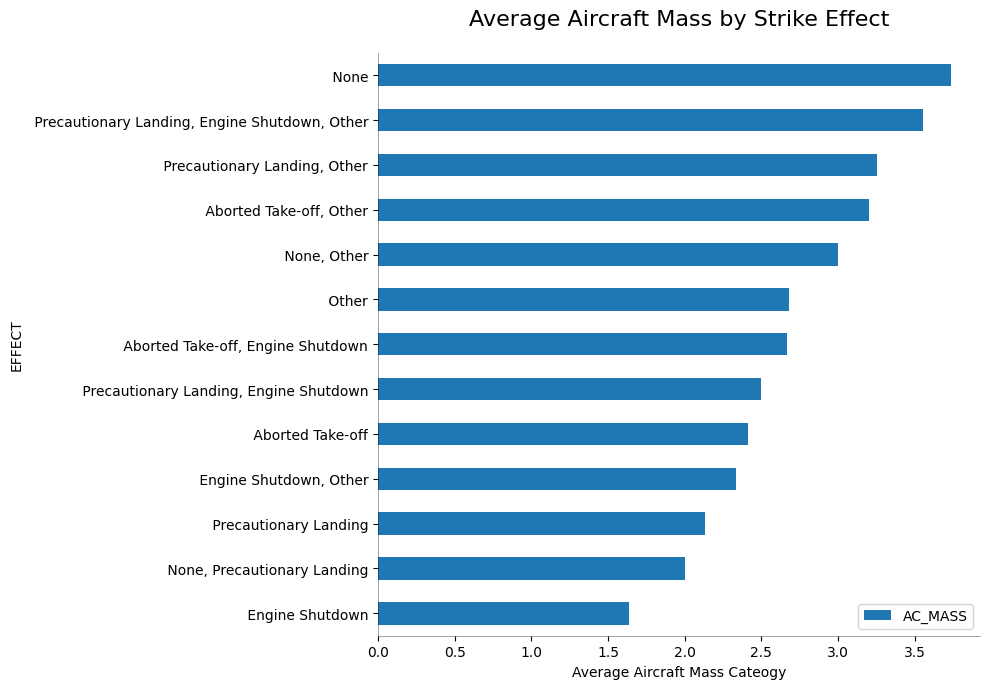

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
effect_mass.plot(kind='barh', ax=ax)

plt.xlabel("Average Aircraft Mass Cateogy")
plt.ylabel("EFFECT")
plt.title("Average Aircraft Mass by Strike Effect", fontsize=16, pad=20)
plt.legend()

worst_effect = ""
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()


In [138]:
df['HEIGHT'].describe()

count    26486.000000
mean       961.765121
std       1911.914579
min          0.000000
25%          0.000000
50%         50.000000
75%       1000.000000
max      32000.000000
Name: HEIGHT, dtype: float64

In [140]:
bin_height = [0, 50, 500, 1000, 5000, 32000]

labels = ['Ground (0-50ft)', 'Low (51-500ft)', 'Pattern (501-1000ft)', 'Approach (1001-5000ft)', 'Cruise (5001ft+)']

df['HEIGHT_BIN'] = pd.cut(df['HEIGHT'], bins=bin_height, labels=labels, include_lowest=True)

print(df['HEIGHT_BIN'].value_counts())

HEIGHT_BIN
Ground (0-50ft)           13869
Approach (1001-5000ft)     5331
Low (51-500ft)             4121
Pattern (501-1000ft)       2148
Cruise (5001ft+)           1017
Name: count, dtype: int64


### Cleaning the Data
* After my initial observations of the data - I have decided to eliminate the following columns:
* <u>REDUNDANT DATE FIELDS</u>
    * `INCIDENT_MONTH`
    * `INCIDENT_YEAR`
* <u>ADMINISTRATIVE COLUMNS</u>
    * `INDX_NR` - Database index.
    * `LUPDATE` - last update timestamp
    * `TRANSFER` - Transfer tag
    * `IMAGE` - Boolean for whether a phot was taken, not useful.
    * `REPORTER_NAME` - Mostly redacted
    * `REPORTER_TITLE` - Mostly redacted
    * `PERSON` - Redacted
    * `FLT`
    * `REG`
* <u>MISSING DATA</u>
    * `BIRD_BAND_NUMBER`
    * `ENG_4_POS`
    * `COST_REPAIRS`
    * `EFFECT_OTHER`
    * `ENG_3_POS`
    * `COST_OTHER_INFL_ADJ`
    * `COST_OTHER`
    * `ENROUTE_STATE`
    * `AOS`
    * `OTHER_SPECIFY`
    * `LOCATION`
    * `INJESTED_OTHER`
* <u>AIRCRAFT MAKE/MODEL CODES MADE REDUNDANT BY `AIRCRAFT`</u>
    * `AMA`
    * `AMO`
    * `EMA`
    * `EMO`

In [ ]:
df_clean = df.drop(['INCIDENT_MONTH','INCIDENT_YEAR','INDX_NR','LUPDATE','TRANSFER','IMAGE','REPORTER_NAME','REPORTER_TITLE','PERSON','FLT','REG','BIRD_BAND_NUMBER','ENG_4_POS','COST_REPAIRS','EFFECT_OTHER','ENG_3_POS','COST_OTHER_INFL_ADJ','COST_OTHER','ENROUTE_STATE','AOS','OTHER_SPECIFY','LOCATION','INGESTED_OTHER','AMA','AMO','EMA','EMO','NR_INJURIES', 'NR_FATALITIES'], axis=1)

In [ ]:
df_clean.head(10)

,INCIDENT_DATE,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,AIRPORT_LATITUDE,AIRPORT_LONGITUDE,RUNWAY,STATE,FAAREGION,...,REMARKS,REMAINS_COLLECTED,REMAINS_SENT,WARNED,NUM_SEEN,NUM_STRUCK,SIZE,COMMENTS,SOURCE,TIME_MINUTES
0,2023-01-01,,Night,KJFK,JOHN F KENNEDY INTL,40.63975,-73.77893,22L,NY,AEA,...,RADOME DENT RH SIDE. Flight #: LAE2516 (Latam)...,False,False,Unknown,,1,Large,NaN,Multiple,None
1,2023-01-01,13:49,Day,KLGA,LA GUARDIA ARPT,40.77724,-73.87261,4,NY,AEA,...,1349L ATCT reported UAL795 struck a bird on de...,False,False,Unknown,,1,NaN,NaN,Multiple,None
2,2023-01-01,7:15,NaN,KMOB,MOBILE REGIONAL,30.69142,-88.24283,33,AL,ASO,...,"ENY3864, E170, DEPARTED RWY 33 AND REPORTED A ...",False,False,Unknown,,1,NaN,Revised POF,MOR,None
3,2023-01-01,14:10,NaN,KBOS,GENERAL EDWARD LAWRENCE LOGAN INTL ARPT,42.36435,-71.00518,33L,MA,ANE,...,Pilot departing 33L reported seeing a dead bir...,True,False,Unknown,,1,Medium,NaN,FAA Form 5200-7-E,None
4,2023-01-01,8:50,NaN,KBZN,GALLATIN FIELD ARPT,45.7769,-111.15301,12,MT,ANM,...,No aircraft/pilot reported damage or a strike....,True,False,Unknown,,1,Small,NaN,FAA Form 5200-7-E,None
5,2023-01-01,10:12,NaN,KATL,HARTSFIELD - JACKSON ATLANTA INTL ARPT,33.64044,-84.42694,Taxiway Bravo,GA,ASO,...,"During the daily airfield inspection, ATL Airp...",True,False,Unknown,,1,Small,NaN,FAA Form 5200-7-E,None
6,2023-01-01,10:30,NaN,KIAH,GEORGE BUSH INTERCONTINENTAL/ HOUSTON ARPT,29.98047,-95.33972,8/26,TX,ASW,...,Found during morning RWY inspection. day .DAY.,True,False,Unknown,,1,Small,NaN,FAA Form 5200-7-E,None
7,2023-01-01,8:50,NaN,KTPA,TAMPA INTL,27.97547,-82.53325,1L,FL,ASO,...,Remains located on center during SMGCS inspect...,True,True,Unknown,,1,Small,NaN,FAA Form 5200-7-E,None
8,2023-01-01,10:30,NaN,KAUS,AUSTIN-BERGSTROM INTL,30.19453,-97.66987,18L,TX,ASW,...,"During routine inspection, AUS Airside Operati...",True,False,Unknown,,1,Medium,NaN,FAA Form 5200-7-E,None
9,2023-01-01,20:30,NaN,KSEA,SEATTLE-TACOMA INTL,47.44898,-122.30931,16L,WA,ANM,...,found on runway check. NIGHT,True,False,Unknown,,1,Medium,corrected spelling in remarks,FAA Form 5200-7-E,None
